In [12]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

class MarketScraper:

    def __init__(self):
        # 1. The universal dictionary map for the entire class
        self.mapping_dict = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}

        # 2. The master vault that will hold all scraped data
        self.master_list = []

    def extract_book_data(self, book_pod):
        """
        Takes ONE single book's HTML pod, extracts the metrics,
        and returns a clean Python dictionary.
        """
        book_title = book_pod.h3.a['title']
        book_price = book_pod.find('p', {'class': 'price_color'}).text
        book_instock_status = book_pod.find('p', {'class': 'instock availability'}).text.strip()

        # Rating extraction
        book_rating_element = book_pod.find('p', {'class': 'star-rating'})
        mystery_book_ratings = None

        if book_rating_element:
            book_class_list = book_rating_element['class']
            mystery_book_ratings = book_class_list[1]
            # Convert string to integer using the class attribute
            mystery_book_ratings = self.mapping_dict[mystery_book_ratings]

        return {
            'Title': book_title,
            'Price': book_price,
            'Ratings': mystery_book_ratings,
            'Availability Status': book_instock_status
        }

    def scrape_category(self, start_url):
        """
        Dynamically paginates through a given category URL, scraping all available books.
        """
        num = 1
        print(f"Initiating scraping protocol for: {start_url}...")

        while True:
            # Construct the dynamic URL for the current page
            target_url = f"{start_url}/page-{num}.html"
            r = requests.get(target_url)

            # The Failsafe: Break if the page does not exist
            if r.status_code != 200:
                print(f"Target exhausted. Scraping completed at page {num - 1}.")
                break

            print(f"Successfully breached page {num}...")

            # Parse the HTML and extract the pods
            mystery_soup = BeautifulSoup(r.text, 'html.parser')
            mystery_books = mystery_soup.find_all('article', {'class': 'product_pod'})

            # Loop through the pods, call the extraction method, and store the dictionary
            for book in mystery_books:
                clean_book_dict = self.extract_book_data(book)
                self.master_list.append(clean_book_dict)

            # Increment to target the next page
            num += 1

    def export_to_csv(self, filename):
        """
        Converts the master_list to a Pandas DataFrame, saves it to a CSV,
        and returns the DataFrame for notebook preview.
        """
        df = pd.DataFrame(self.master_list)
        df.to_csv(filename, index=False)
        print(f"SUCCESS: Exported {len(self.master_list)} rows to {filename}.")

        return df

In [25]:
scraper = MarketScraper()
scraper.scrape_category("https://books.toscrape.com/catalogue/category/books/mystery_3")
final_df = scraper.export_to_csv("mystery_competitors.csv")
final_df.head()

Initiating scraping protocol for: https://books.toscrape.com/catalogue/category/books/mystery_3...
Successfully breached page 1...
Successfully breached page 2...
Target exhausted. Scraping completed at page 2.
SUCCESS: Exported 32 rows to mystery_competitors.csv.


,Title,Price,Ratings,Availability Status
0,Sharp Objects,Â£47.82,4,In stock
1,"In a Dark, Dark Wood",Â£19.63,1,In stock
2,The Past Never Ends,Â£56.50,4,In stock
3,A Murder in Time,Â£16.64,1,In stock
4,The Murder of Roger Ackroyd (Hercule Poirot #4),Â£44.10,4,In stock


In [26]:
final_df['Price'] = final_df['Price'].str.replace('Â£', '', regex=False)
final_df['Price'] = final_df['Price'].astype(float)
final_df.head()

,Title,Price,Ratings,Availability Status
0,Sharp Objects,47.82,4,In stock
1,"In a Dark, Dark Wood",19.63,1,In stock
2,The Past Never Ends,56.50,4,In stock
3,A Murder in Time,16.64,1,In stock
4,The Murder of Roger Ackroyd (Hercule Poirot #4),44.10,4,In stock
5,The Last Mile (Amos Decker #2),54.21,2,In stock
6,That Darkness (Gardiner and Renner #1),13.92,1,In stock
7,Tastes Like Fear (DI Marnie Rome #3),10.69,1,In stock
8,A Time of Torment (Charlie Parker #14),48.35,5,In stock
9,A Study in Scarlet (Sherlock Holmes #1),16.73,2,In stock


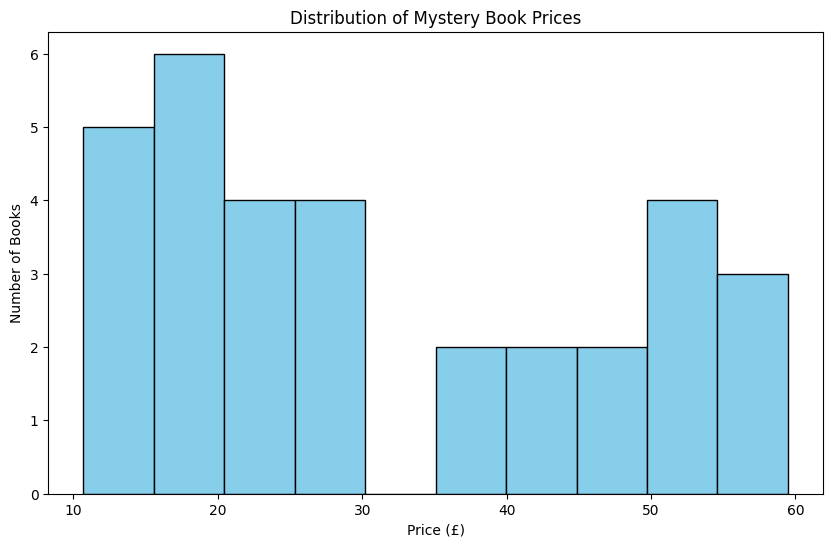

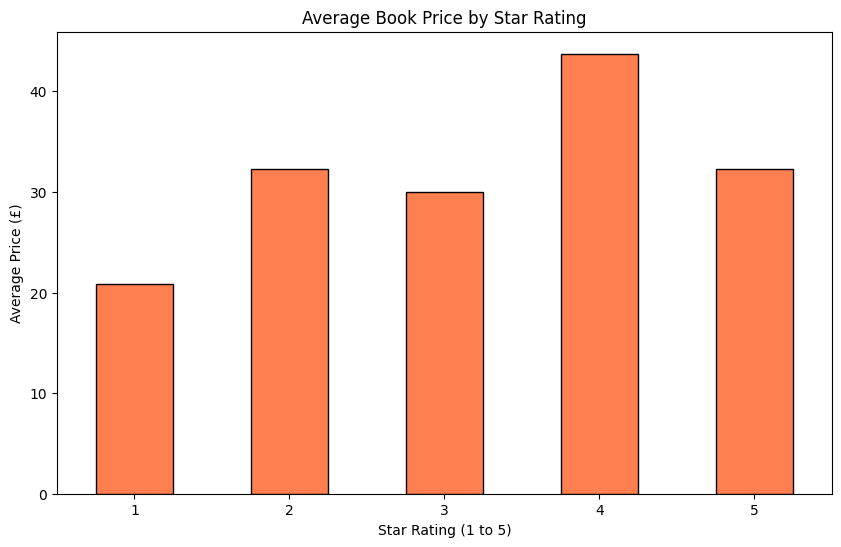

In [27]:
# --- Graph 1: Competitor Price Distribution ---
plt.figure(figsize=(10, 6))
plt.hist(final_df['Price'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Mystery Book Prices')
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.show()

# --- Graph 2: Average Price by Star Rating ---
plt.figure(figsize=(10, 6))
# Calculate the average price for each star rating
avg_price_by_rating = final_df.groupby('Ratings')['Price'].mean().sort_index()

# Create the bar chart
avg_price_by_rating.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Book Price by Star Rating')
plt.xlabel('Star Rating (1 to 5)')
plt.ylabel('Average Price (£)')
plt.xticks(rotation=0) # Keeps the rating numbers upright
plt.show()